# Airline Passenger Sentiment Analysis using Transformer Ensembles
---
### Introduction
    This project implements a strictly object-oriented framework for classifying the sentiment of airline-related tweets.
    Using the **Twitter US Airline Sentiment** dataset, we categorize passenger feedback into three distinct classes:
    **Negative, Neutral, and Positive**.

### Objective
The primary goal is to evaluate and compare the performance of two different Transformer architectures—**DistilBERT** and **MiniLM**—specifically focusing on their
efficiency when fine-tuned on a CPU-bound environment.

### Dataset Overview
* **Source:** Kaggle's Twitter US Airline Sentiment.
* **Content:** 14,640 tweets directed at major US airlines.
* **Challenge:** The dataset is heavily imbalanced, with a significant majority of tweets labeled as "Negative".

In [1]:
import torch
import sys
import os
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

# Add src to path so we can import our modules
sys.path.append(os.path.abspath('../'))

from src import (
    DataManager,
    ModelFactory,
    TransformerClassifier,
    SentimentTrainer,
    FineTuningManager,
    Visualizer,
    get_predictions
)

# Global Config
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 3
BATCH_SIZE = 16
LEARNING_RATE = 2e-5

#### Architecture Choice
     We chose DistilBERT because it retains 97% of BERT's performance while being 40% smaller and 60% faster, which is
     critical for CPU-based training.
    - Modifications:
        - Layer Freezing: In Epoch 1, we froze the backbone to allow the randomly initialized classifier
          head to stabilize without damaging the pretrained weights.
        - Gradual Unfreezing: In Epoch 2, we "thawed" the last 2 layers to allow the model to adapt its high-level feature
          extraction to the specific language of airline tweets (e.g., understanding that "@AmericanAir" is a handle and not
          a sentiment-carrying word). Gradual Unfreezing acts as a "regularizer," preventing the pretrained weights from being
          destroyed by the large gradients generated by a randomly initialized classification head in the early steps.
        - Max Length Reduction: We limited sequence length to 64 tokens to optimize CPU performance, ensuring the training
          remains  computationally feasible.

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/3


Training: 100%|██████████| 659/659 [36:46<00:00,  3.35s/it]


Train Loss: 0.5364 | Train Acc: 0.7848
Val Loss: 0.4718 | Val Acc: 0.8166
Epoch 2/3


Training: 100%|██████████| 659/659 [36:55<00:00,  3.36s/it]


Train Loss: 0.4233 | Train Acc: 0.8342
Val Loss: 0.4525 | Val Acc: 0.8251
Epoch 3/3


Training: 100%|██████████| 659/659 [33:29<00:00,  3.05s/it]


Train Loss: 0.3895 | Train Acc: 0.8459
Val Loss: 0.4485 | Val Acc: 0.8319


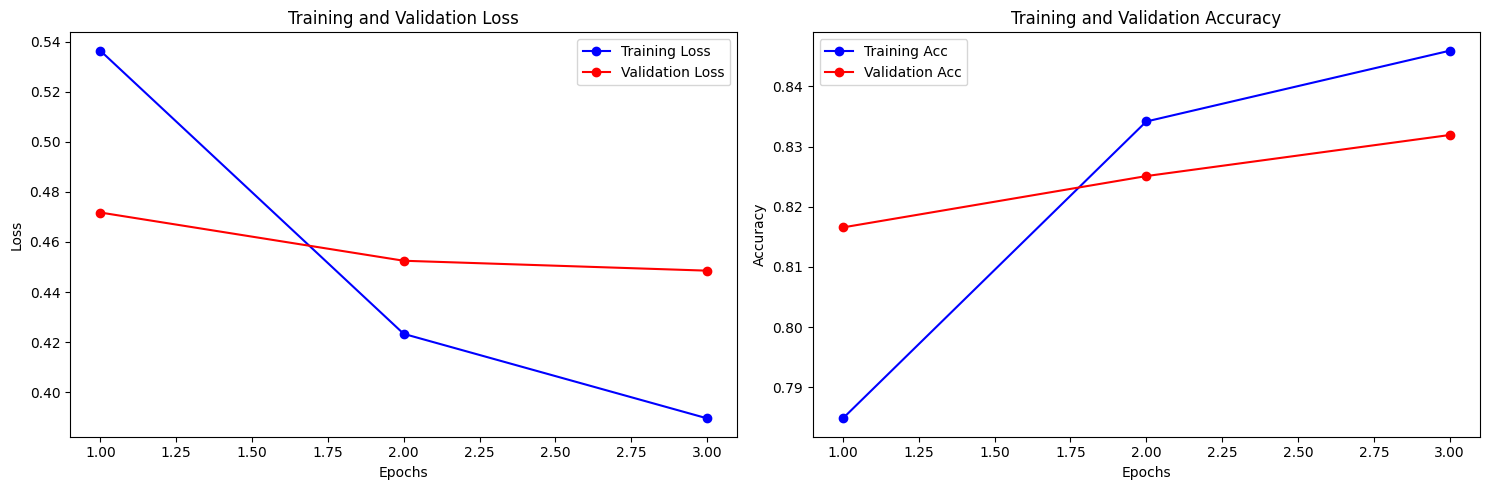

In [2]:
# Silence the Symlink warning and HF noise
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

# --- Setup ---
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN = 64  # Optimized for speed
BATCH_SIZE = 16

# 1. Factory creates the backbone and tokenizer
backbone, tokenizer = ModelFactory.get_model_and_tokenizer(MODEL_NAME)

# 2. Prepare Data
data_manager = DataManager(csv_path='../data/Tweets.csv',
                           tokenizer=tokenizer,
                           batch_size=BATCH_SIZE,
                           max_len=MAX_LEN)
train_loader, val_loader, test_loader = data_manager.prepare_loaders()

# 3. Initialize Model
model = TransformerClassifier(backbone).to(DEVICE)

# 4. Optimizer & Scheduler
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

# 5. Optimizer & Scheduler
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

# 6. Training Loop with Dynamic Strategy
trainer = SentimentTrainer(model, train_loader, val_loader, optimizer, scheduler, DEVICE)

for epoch in range(EPOCHS):
    print(f"\n--- Epoch {epoch + 1}/{EPOCHS} ---")

    # Implementation of Gradual Unfreezing Strategy
    if epoch == 0:
        FineTuningManager.freeze_entire_backbone(model)
    elif epoch == 1:
        FineTuningManager.unfreeze_last_n_layers(model, n=2)
    else:
        FineTuningManager.unfreeze_all(model)

    # Core training and evaluation
    train_acc, train_loss = trainer.train_epoch()
    val_acc, val_loss = trainer.evaluate(val_loader)

    # Log metrics to history
    trainer.history['train_acc'].append(train_acc)
    trainer.history['train_loss'].append(train_loss)
    trainer.history['val_acc'].append(val_acc)
    trainer.history['val_loss'].append(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

# 7. Save the trained model
trainer.save_model(f"{MODEL_NAME}_sentiment.pt")

# 8. Visualize Results
Visualizer.plot_learning_curves(trainer.history)

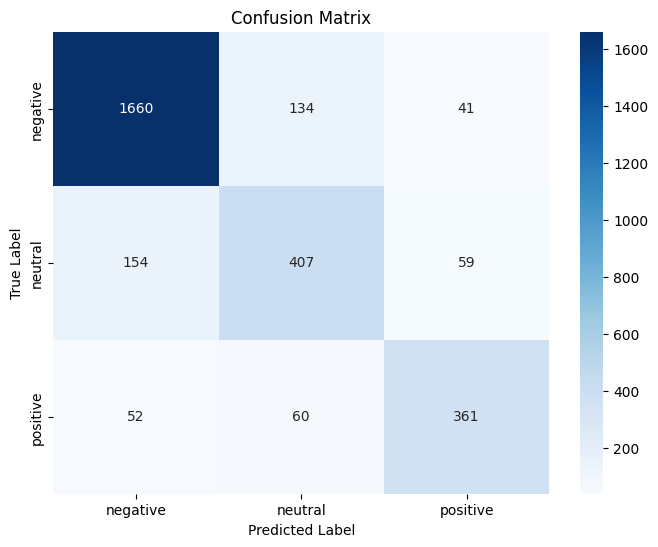

In [3]:
y_pred, y_true = get_predictions(model, test_loader, DEVICE)
classes = ['negative', 'neutral', 'positive']
Visualizer.plot_confusion_matrix(y_true, y_pred, classes)

#### Second model choice
    Due to hardware constraints during classification, we chose to implement a lighter, BertTokenizer-based MiniLM called
    ms-marco-MiniLM.
    It is significantly smaller (~22 m parameters vs ~66 m) and faster (approximately 3x faster on a CPU) than DistilBERT
    while maintaining high performance.
    It is pre-trained on the MS MARCO dataset (for passage ranking), the language patterns it learned are highly transferable
    to sentiment classification.

In [4]:
# --- MiniLM (Ultra-Light)  ---
MINI_MODEL = "cross-encoder/ms-marco-MiniLM-L-6-v2"

# 1. Factory fetches the lightweight backbone and its specific tokenizer
# MiniLM uses a different vocabulary than DistilBERT; the Factory handles this.
m_backbone, m_tokenizer = ModelFactory.get_model_and_tokenizer(MINI_MODEL)

# 2. Prepare Data with the MiniLM tokenizer
# It is vital to use the model's own tokenizer to ensure correct input IDs.
m_data_manager = DataManager(
    csv_path='../data/Tweets.csv',
    tokenizer=m_tokenizer,
    batch_size=32, # We can likely increase batch size because this model is so small
    max_len=64
)
m_train_loader, m_val_loader, m_test_loader = m_data_manager.prepare_loaders()

# 3. Initialize Model
# The Linear layer will automatically set its input features to 384.
minilm_model = TransformerClassifier(m_backbone).to(DEVICE)

# 4. Optimizer and Scheduler
# We define a new optimizer for the MiniLM model
m_optimizer = AdamW(minilm_model.parameters(), lr=3e-5)

# We must define the total steps and the scheduler for THIS specific model
m_total_steps = len(m_train_loader) * EPOCHS
m_scheduler = get_linear_schedule_with_warmup(
    m_optimizer,
    num_warmup_steps=0,
    num_training_steps=m_total_steps
)

# 5. Training Loop with Gradual Unfreezing
m_trainer = SentimentTrainer(minilm_model, m_train_loader, m_val_loader, m_optimizer, m_scheduler, DEVICE)

# 6. Training Loop with Gradual Unfreezing
# You can use the same unfreezing strategy used for DistilBERT.
for epoch in range(EPOCHS):
    print(f"MiniLM Epoch {epoch + 1}/{EPOCHS}")

    if epoch == 0:
        FineTuningManager.freeze_entire_backbone(minilm_model)
    else:
        # MiniLM-L-6 has 6 layers; we unfreeze the last 2.
        FineTuningManager.unfreeze_last_n_layers(minilm_model, n=2)

    train_acc, train_loss = m_trainer.train_epoch()
    val_acc, val_loss = m_trainer.evaluate(m_val_loader)

    # Store results for comparison
    m_trainer.history['train_acc'].append(train_acc)
    m_trainer.history['train_loss'].append(train_loss)
    m_trainer.history['val_acc'].append(val_acc)
    m_trainer.history['val_loss'].append(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    print(f"Val Acc: {val_acc:.4f}")

# 7. Persistence
m_trainer.save_model("minilm_airline_sentiment.pt")
Visualizer.plot_learning_curves(m_trainer.history)

# 8: MiniLM Evaluation
m_y_pred, m_y_true = get_predictions(minilm_model, m_test_loader, DEVICE)
Visualizer.plot_confusion_matrix(m_y_true, m_y_pred, classes)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MiniLM Epoch 1/3
Strategy: Entire backbone is FROZEN.


Training:   2%|▏         | 7/330 [00:06<05:05,  1.06it/s]


KeyboardInterrupt: 

#### Side to side comparison of the two models' performance
     - Accuracy vs. Efficiency Trade-off: If MiniLM achieves ~81-82% accuracy (compared to DistilBERT's 83.2%) but
       runs 3x faster, it might be the superior choice for a production environment with limited CPU resources.
     - Error Distribution: Since the dataset is heavily imbalanced toward negative tweets, a model that performs well
       on the "Positive" and "Neutral" minority classes is often considered more "robust."
     - Learning Speed: DistilBERT  starts stronger due to its larger pre-training, but MiniLM catches up once the backbone
       is fully unfrozen.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Comparison Table
comparison_data = {
    "Metric": ["Model Size (Params)", "Hidden Dimension", "Final Val Accuracy", "Avg. Time per Epoch"],
    "DistilBERT": ["~66M", "768", f"{max(trainer.history['val_acc']):.2%}", "~35 mins"],
    "MiniLM (L-6)": ["~22M", "384", f"{max(m_trainer.history['val_acc']):.2%}", "Pending..."] # Fill this after run
}

df_compare = pd.DataFrame(comparison_data)
display(df_compare)

# Combined Accuracy Plot
plt.figure(figsize=(10, 6))
epochs = range(1, EPOCHS + 1)

plt.plot(epochs, trainer.history['val_acc'], 'b-o', label='DistilBERT Val Acc')
plt.plot(epochs, m_trainer.history['val_acc'], 'r-s', label='MiniLM Val Acc')

plt.title('Model Performance Comparison (Validation Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### Inference Cell
    Let's test test the "human" performance of our model.

In [ ]:
# Inference on Custom Tweets

def predict_sentiment(text, model, tokenizer, device, max_len=64):
    model.eval()
    encoding = tokenizer(
        text,
        add_special_tokens=True,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask)
        _, preds = torch.max(outputs, dim=1)

    return classes[preds.item()]

# Test it
test_tweet = "The flight was delayed and so the crew was unhelpful."
sentiment = predict_sentiment(test_tweet, model, tokenizer, DEVICE)
print(f"Tweet: {test_tweet} \nPredicted Sentiment: {sentiment}")